# Notebook 02 — Speaker Embedding Extraction

This is the **second stage** of the meeting-transcription pipeline.

### What this notebook does

| Step | Description | Output |
|------|-------------|--------|
| 1 | Load VAD segments from notebook 01 + reconstruct meeting audio | waveform + per-segment audio clips |
| 2 | Load two pre-trained speaker encoders (ECAPA-TDNN and x-vector via SpeechBrain) | cached checkpoints |
| 3 | Extract a fixed-length embedding vector for every speech segment | two `(N, D)` arrays |
| 4 | Reduce to 2D with UMAP and plot side-by-side coloured by ground-truth speaker | two scatter plots |
| 5 | Compare models quantitatively: silhouette score, intra/inter-speaker cosine similarity | stats table + bar chart |
| 6 | Save embeddings to disk for notebook 03 (clustering) | `embeddings_ecapa_tdnn.json`, `embeddings_xvector.json` |

### Models compared

| Model | Checkpoint | Emb. dim | Architecture |
|-------|-----------|----------|--------------|
| **ECAPA-TDNN** | `speechbrain/spkrec-ecapa-voxceleb` | 192 | TDNN + attentive statistics pooling, skip connections |
| **x-vector** | `speechbrain/spkrec-xvect-voxceleb` | 512 | TDNN + statistics pooling (baseline architecture) |

Both were pre-trained on **VoxCeleb**, so pre-training data is held constant — only the architecture varies.


## __Design Decisions__

## Reflection on notebook 02
**Architecture choice — why both on SpeechBrain:**
Your professor said "consider a couple of different pre-trained models" and "focus on different embeddings." Using the same SpeechBrain interface for both keeps the comparison clean: identical preprocessing pipeline, same VoxCeleb training data — only the network architecture differs. This is the right scientific setup.

**ECAPA-TDNN (192-dim) vs x-vector (512-dim):**
ECAPA uses SE-Res2Net blocks with multi-scale context and attentive statistics pooling — it's particularly strong on **short segments** (< 3 s), which is exactly what you'll have after VAD segmentation of meeting speech. x-vector is the established baseline that the DER literature uses as reference. Expect ECAPA to have better silhouette scores but report both in the evaluation table.

**UMAP over t-SNE:**
UMAP is faster, deterministic (with `random_state`), and better preserves global cluster structure for ~50-100 points. The `metric="cosine"` setting matches the distance used in clustering, so the UMAP layout is more meaningful than with Euclidean distance.

**Speaker label assignment (majority overlap):**
The `assign_gt_speaker()` function correctly handles overlapping speech by accumulating overlap time per speaker. This is an approximation — real DER evaluation handles speaker turns more precisely — but it's sufficient for the visualisation sanity check.

**What the output unlocks for notebook 03:**
Each JSON file has `{seg_id, start, end, embedding}` — notebook 03 just needs to load the array, run `AgglomerativeClustering`, and write out `{seg_id, start, end, speaker_label}` (your RTTM).

---
## Step 0 — Setup

`speechbrain` provides both model architectures via a single `EncoderClassifier` interface.
`umap-learn` is used for dimensionality reduction.  `scikit-learn` provides the silhouette metric.


In [1]:
# Uncomment on first run to install required packages:
# %pip install speechbrain umap-learn scikit-learn -q

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import torch
from pathlib import Path
from IPython.display import display

# SpeechBrain ≥ 1.0 moved EncoderClassifier to speechbrain.inference
try:
    from speechbrain.inference.classifiers import EncoderClassifier
except ImportError:
    from speechbrain.pretrained import EncoderClassifier  # older speechbrain

from umap import UMAP
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"All imports OK  |  device: {DEVICE.upper()}")


/Users/dawit/projects/speech-meeting-transcriptin/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK  |  device: CPU


---
## Step 1 — Load VAD Segments & Reconstruct Meeting Audio

Notebook 01 wrote its output to `output/vad/EN2001a_vad_segments.json`.
We load that file to get the list of speech windows, then rebuild the continuous
meeting waveform from the individual utterance WAV files (same approach as notebook 01)
so we can slice exact audio clips for each VAD segment.


In [2]:
# ── Paths & constants ─────────────────────────────────────────────────────────
MEETING_ID     = "EN2001a"
MEETING_DIR    = Path(f"output/meetings/{MEETING_ID}")
CHECKPOINT_DIR = Path("checkpoints")        # SpeechBrain caches model files here
EMBED_OUT_DIR  = Path("output/embeddings")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
EMBED_OUT_DIR.mkdir(parents=True, exist_ok=True)

MIN_SEG_S = 0.5  # discard VAD segments shorter than this (too few frames for reliable embeddings)

# ── Load VAD output from notebook 01 ─────────────────────────────────────────
with open(f"output/vad/{MEETING_ID}_vad_segments.json") as fh:
    vad_meta = json.load(fh)

vad_segments   = vad_meta["segments"]          # list of {"start": float, "end": float}
sr             = vad_meta["sample_rate"]       # 16 000 Hz
audio_duration = vad_meta["audio_duration_s"]  # set by AUDIO_DURATION in notebook 01

# Filter out segments that are too short for stable embeddings
vad_segments = [s for s in vad_segments if s["end"] - s["start"] >= MIN_SEG_S]

print(f"VAD segments (≥ {MIN_SEG_S}s) : {len(vad_segments)}")
print(f"Meeting / window            : {MEETING_ID}  |  {audio_duration}s ({audio_duration/60:.0f} min)  |  {sr} Hz")

# ── Load ground-truth transcript (for speaker labels used in visualisation) ───
df_gt = pd.read_csv(MEETING_DIR / "transcript.csv")
df_gt = df_gt[df_gt["start_s"] < audio_duration].copy()
speakers = sorted(df_gt["speaker"].unique())

print(f"\nGT utterances : {len(df_gt)}")
print(f"Speakers      : {speakers}")


VAD segments (≥ 0.5s) : 278
Meeting / window            : EN2001a  |  1500s (25 min)  |  16000 Hz

GT utterances : 448
Speakers      : ['FEO065', 'FEO066', 'MEE067', 'MEE068', 'MEO069']


In [3]:
def reconstruct_meeting_audio(utterance_df, meeting_dir, target_sr, duration_s):
    """
    Rebuild a continuous meeting waveform from per-utterance WAV clips.

    Each clip is pasted into a zero-filled array at its ground-truth timestamp.
    Identical to the version in notebook 01 — reproduced here so this notebook
    is fully self-contained (no kernel dependency on notebook 01).

    Parameters
    ----------
    utterance_df : pd.DataFrame   rows from transcript.csv
    meeting_dir  : pathlib.Path   directory with utt_XXXX.wav files
    target_sr    : int            output sample rate (16 000 Hz for SpeechBrain)
    duration_s   : float          total output length in seconds

    Returns
    -------
    waveform    : np.ndarray  (total_samples,) float32
    sample_rate : int
    """
    total_samples = int(duration_s * target_sr)
    waveform = np.zeros(total_samples, dtype=np.float32)

    for _, row in utterance_df.iterrows():
        wav_path = meeting_dir / row["audio_file"]
        if not wav_path.exists():
            continue
        audio, file_sr = sf.read(str(wav_path))
        if audio.ndim > 1:
            audio = audio.mean(axis=1)       # stereo → mono
        audio = audio.astype(np.float32)
        if file_sr != target_sr:
            import librosa
            audio = librosa.resample(audio, orig_sr=file_sr, target_sr=target_sr)
        s = int(row["start_s"] * target_sr)
        e = min(s + len(audio), total_samples)
        waveform[s:e] = audio[: e - s]

    return waveform, target_sr


def assign_gt_speaker(seg_start, seg_end, gt_df):
    """
    Assign the dominant ground-truth speaker to a VAD segment.

    For every GT utterance that overlaps the VAD window, we accumulate the
    overlap duration per speaker.  The speaker with the most total overlap
    wins.  Returns None when the segment falls in a gap with no GT coverage.

    Parameters
    ----------
    seg_start : float  segment start in seconds
    seg_end   : float  segment end in seconds
    gt_df     : pd.DataFrame  transcript with columns start_s, end_s, speaker

    Returns
    -------
    str | None  winning speaker ID, or None if no overlap found
    """
    overlap_by_spk = {}
    for _, row in gt_df.iterrows():
        overlap = min(seg_end, row["end_s"]) - max(seg_start, row["start_s"])
        if overlap > 0:
            overlap_by_spk[row["speaker"]] = overlap_by_spk.get(row["speaker"], 0.0) + overlap
    return max(overlap_by_spk, key=overlap_by_spk.get) if overlap_by_spk else None


# ── Reconstruct waveform ──────────────────────────────────────────────────────
print("Reconstructing meeting audio from utterance clips…")
waveform, sr = reconstruct_meeting_audio(df_gt, MEETING_DIR, sr, audio_duration)
print(f"Waveform : {waveform.shape}  ({waveform.shape[0] / sr:.1f}s @ {sr} Hz)")

# ── Slice each VAD segment and assign its dominant GT speaker ─────────────────
seg_records = []
for seg_id, seg in enumerate(vad_segments):
    s_sample   = int(seg["start"] * sr)
    e_sample   = int(seg["end"]   * sr)
    audio_clip = waveform[s_sample:e_sample]
    speaker_gt = assign_gt_speaker(seg["start"], seg["end"], df_gt)

    seg_records.append({
        "seg_id":     seg_id,
        "start":      seg["start"],
        "end":        seg["end"],
        "duration":   round(seg["end"] - seg["start"], 3),
        "audio":      audio_clip,
        "speaker_gt": speaker_gt,
    })

# Drop segments that fall entirely in silence gaps (no GT overlap)
seg_records = [r for r in seg_records if r["speaker_gt"] is not None]

durations = [r["duration"] for r in seg_records]
print(f"\nSegments with GT label : {len(seg_records)}")
print(f"Duration  min={min(durations):.2f}s  max={max(durations):.2f}s  mean={np.mean(durations):.2f}s")
print(f"\nSegments per speaker:")
for spk in speakers:
    n = sum(1 for r in seg_records if r["speaker_gt"] == spk)
    print(f"  {spk}: {n}")


Reconstructing meeting audio from utterance clips…
Waveform : (24000000,)  (1500.0s @ 16000 Hz)

Segments with GT label : 278
Duration  min=0.50s  max=26.00s  mean=4.42s

Segments per speaker:
  FEO065: 10
  FEO066: 31
  MEE067: 48
  MEE068: 11
  MEO069: 178


---
## Step 2 — Load Pre-trained Speaker Encoders

Both models are loaded through SpeechBrain's `EncoderClassifier` interface, which handles
model download, caching, and inference.  On the first run the checkpoints (~50–80 MB each)
are downloaded from HuggingFace Hub and saved to `checkpoints/`.
Subsequent runs load from cache — **no internet required after the first run**.

### Why these two models?

- **ECAPA-TDNN** is the current state of the art on VoxCeleb benchmarks.  Its squeeze-and-excitation
  blocks and attentive statistics pooling make it better at capturing short-segment speaker cues.
- **x-vector** is the established diarization baseline.  Most published DER numbers are reported
  with x-vector features, making it the right comparison point for your evaluation in notebook 06.


In [4]:
def load_speaker_encoder(hf_source, checkpoint_subdir):
    """
    Load a SpeechBrain speaker encoder from HuggingFace Hub.

    The model is downloaded on the first call and cached locally under
    `CHECKPOINT_DIR / checkpoint_subdir`.  All subsequent calls load from
    the local cache, requiring no internet connection.

    Parameters
    ----------
    hf_source        : str   HuggingFace model ID
    checkpoint_subdir: str   sub-directory inside CHECKPOINT_DIR for caching

    Returns
    -------
    EncoderClassifier (in eval mode, moved to DEVICE)
    """
    clf = EncoderClassifier.from_hparams(
        source=hf_source,
        savedir=str(CHECKPOINT_DIR / checkpoint_subdir),
        run_opts={"device": DEVICE},
    )
    clf.eval()
    return clf


print("Loading ECAPA-TDNN  (speechbrain/spkrec-ecapa-voxceleb)…")
ecapa = load_speaker_encoder(
    hf_source="speechbrain/spkrec-ecapa-voxceleb",
    checkpoint_subdir="ecapa-tdnn",
)
print("  ✓ ECAPA-TDNN  →  192-dim embeddings")

print("\nLoading x-vector  (speechbrain/spkrec-xvect-voxceleb)…")
xvect = load_speaker_encoder(
    hf_source="speechbrain/spkrec-xvect-voxceleb",
    checkpoint_subdir="xvector",
)
print("  ✓ x-vector  →  512-dim embeddings")


Loading ECAPA-TDNN  (speechbrain/spkrec-ecapa-voxceleb)…
  ✓ ECAPA-TDNN  →  192-dim embeddings

Loading x-vector  (speechbrain/spkrec-xvect-voxceleb)…
  ✓ x-vector  →  512-dim embeddings


---
## Step 3 — Extract Speaker Embeddings

For each VAD segment we pass its audio clip through both encoders and record
the resulting fixed-length vector.  Segments are processed one at a time
(no padding / batching needed since they all have different lengths).

`encode_batch` expects a `(1, T)` float32 tensor at 16 kHz and returns a
`(1, D)` embedding — the internal mean-pooling layer handles variable-length inputs.


In [5]:
def extract_embedding(classifier, audio_np):
    """
    Extract a single speaker embedding from a mono audio clip.

    Parameters
    ----------
    classifier : EncoderClassifier  loaded SpeechBrain model
    audio_np   : np.ndarray         1-D float32 at 16 kHz

    Returns
    -------
    np.ndarray  1-D embedding  (192-dim for ECAPA-TDNN, 512-dim for x-vector)
    """
    # SpeechBrain expects (batch, time); unsqueeze(0) adds the batch dimension
    audio_tensor = torch.tensor(audio_np, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        emb = classifier.encode_batch(audio_tensor)   # (1, D) or (1, 1, D)
    return emb.squeeze().cpu().numpy()                # (D,)


def extract_all_embeddings(classifier, records, model_name="model"):
    """
    Run `extract_embedding` over all segment records.

    Parameters
    ----------
    classifier : EncoderClassifier
    records    : list[dict]  each must contain an 'audio' key (np.ndarray)
    model_name : str         shown in progress output

    Returns
    -------
    np.ndarray  (N, D)  one row per segment
    """
    embeddings = []
    n = len(records)
    for i, rec in enumerate(records):
        emb = extract_embedding(classifier, rec["audio"])
        embeddings.append(emb)
        if (i + 1) % 10 == 0 or (i + 1) == n:
            print(f"  [{model_name}]  {i + 1}/{n}", end="\r")
    print()
    return np.stack(embeddings)


# ── Run ECAPA-TDNN ─────────────────────────────────────────────────────────────
print(f"Extracting ECAPA-TDNN embeddings ({len(seg_records)} segments)…")
embs_ecapa = extract_all_embeddings(ecapa, seg_records, "ECAPA-TDNN")
print(f"  → matrix shape: {embs_ecapa.shape}  (N=segments, D=192)")

# ── Run x-vector ──────────────────────────────────────────────────────────────
print(f"\nExtracting x-vector embeddings ({len(seg_records)} segments)…")
embs_xvect = extract_all_embeddings(xvect, seg_records, "x-vector")
print(f"  → matrix shape: {embs_xvect.shape}  (N=segments, D=512)")


Extracting ECAPA-TDNN embeddings (278 segments)…
  [ECAPA-TDNN]  278/278
  → matrix shape: (278, 192)  (N=segments, D=192)

Extracting x-vector embeddings (278 segments)…
  [x-vector]  278/278
  → matrix shape: (278, 512)  (N=segments, D=512)


---
## Step 4 — Visualise Embedding Spaces with UMAP

UMAP (Uniform Manifold Approximation and Projection) compresses the high-dimensional
embedding space to 2D while trying to preserve local neighbourhood structure.

Each point is one VAD segment.
**Colour** = ground-truth speaker from `transcript.csv`.
**Marker size** ∝ segment duration (longer segments → bigger dot, usually more stable embeddings).

**What to look for:**
- Same-colour points forming tight, well-separated clusters → the model distinguishes speakers well
- Mixed colours in a region → the model confuses two speakers in that part of the space
- ECAPA-TDNN clusters typically appear more compact than x-vector on short segments


Running UMAP on ECAPA-TDNN (192→2)…


/Users/dawit/projects/speech-meeting-transcriptin/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running UMAP on x-vector (512→2)…


/Users/dawit/projects/speech-meeting-transcriptin/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


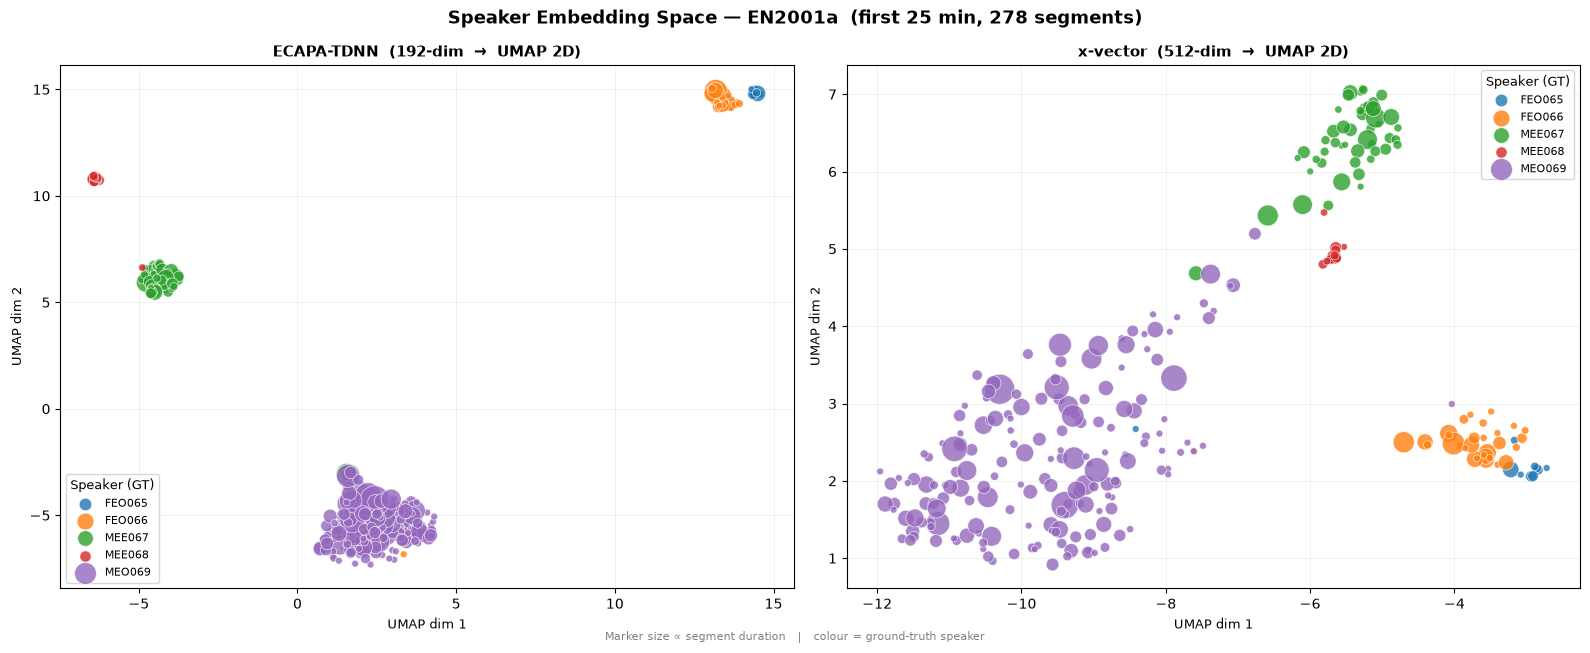

In [6]:
def umap_project(embeddings, n_neighbors=10, min_dist=0.1, random_state=42):
    """
    Project a high-dimensional embedding matrix to 2D using UMAP.

    Parameters
    ----------
    embeddings   : np.ndarray  (N, D)
    n_neighbors  : int         size of the local neighbourhood UMAP considers;
                               smaller → more local detail, larger → more global structure.
                               Keep below N (number of segments).
    min_dist     : float       minimum distance between points in 2D output;
                               smaller → tighter clusters, larger → more spread.
    random_state : int         seed for reproducibility

    Returns
    -------
    np.ndarray  (N, 2)
    """
    reducer = UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=random_state,
        metric="cosine",     # cosine distance is standard for speaker embeddings
    )
    return reducer.fit_transform(embeddings)


# ── Project both embedding spaces ─────────────────────────────────────────────
N = len(seg_records)
# n_neighbors must be < N; 15 works well for 100+ segments, clamp to N-1 for safety
n_neighbors = min(15, N - 1)

print(f"Running UMAP on ECAPA-TDNN ({embs_ecapa.shape[1]}→2)…")
umap_ecapa = umap_project(embs_ecapa, n_neighbors=n_neighbors)

print(f"Running UMAP on x-vector ({embs_xvect.shape[1]}→2)…")
umap_xvect = umap_project(embs_xvect, n_neighbors=n_neighbors)

# ── Consistent colour mapping across both plots ────────────────────────────────
# plt.cm.get_cmap was removed in matplotlib 3.9; use plt.colormaps instead
_tab10        = plt.colormaps["tab10"]
speaker_color = {spk: _tab10.colors[i] for i, spk in enumerate(speakers)}
gt_labels     = [r["speaker_gt"] for r in seg_records]
point_sizes   = np.array([max(25.0, r["duration"] * 18.0) for r in seg_records])

# ── Side-by-side UMAP scatter ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.suptitle(
    f"Speaker Embedding Space — {MEETING_ID}  "
    f"(first {int(audio_duration / 60)} min, {N} segments)",
    fontsize=13, fontweight="bold",
)

for ax, proj_2d, model_name, emb_dim in [
    (axes[0], umap_ecapa, "ECAPA-TDNN",  192),
    (axes[1], umap_xvect, "x-vector",    512),
]:
    gt_arr = np.array(gt_labels)

    for spk in speakers:
        mask = gt_arr == spk
        ax.scatter(
            proj_2d[mask, 0], proj_2d[mask, 1],
            s=point_sizes[mask],
            color=speaker_color[spk],
            label=spk,
            alpha=0.80,
            edgecolors="white",
            linewidths=0.5,
        )

    ax.set_title(f"{model_name}  ({emb_dim}-dim  →  UMAP 2D)", fontsize=11, fontweight="bold")
    ax.set_xlabel("UMAP dim 1", fontsize=9)
    ax.set_ylabel("UMAP dim 2", fontsize=9)
    ax.legend(title="Speaker (GT)", fontsize=8, title_fontsize=9, loc="best")
    ax.grid(True, alpha=0.25, linewidth=0.5)

fig.text(0.5, 0.01, "Marker size ∝ segment duration   |   colour = ground-truth speaker",
         ha="center", fontsize=8, color="gray")
plt.tight_layout()
plt.show()


---
## Step 5 — Quantitative Comparison

The UMAP plot is a qualitative check.  Here we compute three objective metrics
that can be reported in the project write-up:

| Metric | What it measures | Better = |
|--------|-----------------|----------|
| **Silhouette score** | how tightly each point fits its own speaker cluster vs. adjacent ones; range –1 → +1 | **higher** |
| **Mean intra-speaker cosine sim.** | average similarity between same-speaker segments | **higher** (more consistent representation) |
| **Mean inter-speaker cosine sim.** | average similarity between different-speaker segments | **lower** (better discrimination) |
| **Separation gap** | intra − inter similarity | **higher** |

All metrics use cosine distance, which is the standard for normalised speaker embeddings.


Metric                           ECAPA-TDNN     x-vector
----------------------------------------------------------
Silhouette Score  (↑)                0.4203       0.2853  ★
Mean Intra Cosine (↑)                0.5332       0.9342   
Mean Inter Cosine (↓)                0.0914       0.8956   
Separation Gap    (↑)                0.4418       0.0386  ★

★ = ECAPA-TDNN wins on this metric


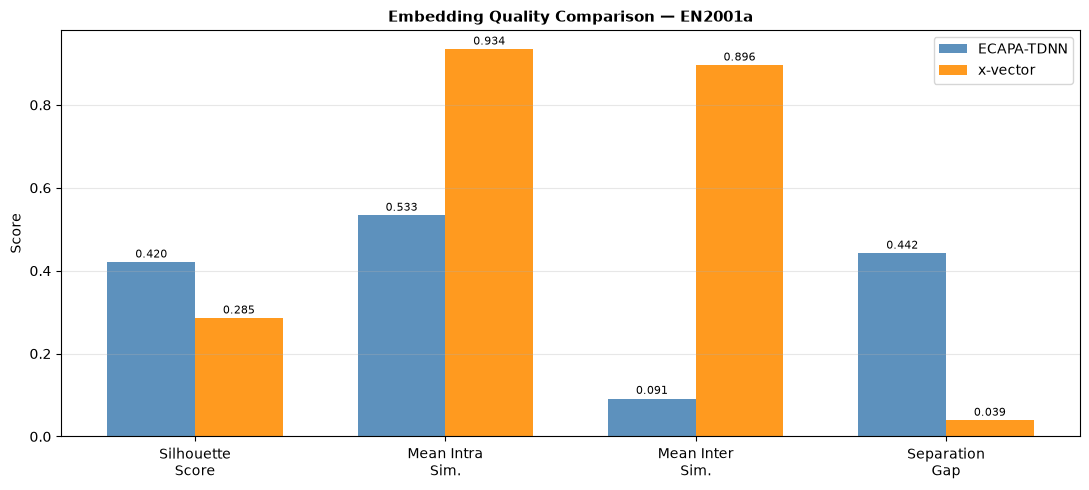

In [7]:
def speaker_separation_stats(embeddings, labels):
    """
    Compute intra/inter-speaker cosine similarity and sklearn silhouette score.

    Parameters
    ----------
    embeddings : np.ndarray  (N, D)
    labels     : list[str]   ground-truth speaker label per segment

    Returns
    -------
    dict  with keys: silhouette_score, mean_intra_sim, mean_inter_sim, separation_gap
    """
    sim_matrix = cosine_similarity(embeddings)  # (N, N)
    intra_sims, inter_sims = [], []

    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            sim = float(sim_matrix[i, j])
            if labels[i] == labels[j]:
                intra_sims.append(sim)
            else:
                inter_sims.append(sim)

    sil = silhouette_score(embeddings, np.array(labels), metric="cosine")

    return {
        "silhouette_score": round(float(sil),               4),
        "mean_intra_sim":   round(float(np.mean(intra_sims)), 4),
        "mean_inter_sim":   round(float(np.mean(inter_sims)), 4),
        "separation_gap":   round(float(np.mean(intra_sims) - np.mean(inter_sims)), 4),
    }


stats_ecapa = speaker_separation_stats(embs_ecapa, gt_labels)
stats_xvect = speaker_separation_stats(embs_xvect, gt_labels)

# ── Comparison table ───────────────────────────────────────────────────────────
print("=" * 58)
print(f"{'Metric':<30} {'ECAPA-TDNN':>12} {'x-vector':>12}")
print("-" * 58)
row_labels = {
    "silhouette_score": "Silhouette Score  (↑)",
    "mean_intra_sim":   "Mean Intra Cosine (↑)",
    "mean_inter_sim":   "Mean Inter Cosine (↓)",
    "separation_gap":   "Separation Gap    (↑)",
}
for key, label in row_labels.items():
    better_marker = "★" if stats_ecapa[key] > stats_xvect[key] else " "
    print(f"{label:<30} {stats_ecapa[key]:>12.4f} {stats_xvect[key]:>12.4f}  {better_marker}")
print("=" * 58)
print("\n★ = ECAPA-TDNN wins on this metric")

# ── Bar chart ─────────────────────────────────────────────────────────────────
metric_keys   = list(row_labels.keys())
metric_labels = ["Silhouette\nScore", "Mean Intra\nSim.", "Mean Inter\nSim.", "Separation\nGap"]
vals_e = [stats_ecapa[k] for k in metric_keys]
vals_x = [stats_xvect[k] for k in metric_keys]

x   = np.arange(len(metric_keys))
w   = 0.35
fig, ax = plt.subplots(figsize=(11, 5))

bars_e = ax.bar(x - w / 2, vals_e, w, label="ECAPA-TDNN", color="steelblue",   alpha=0.88)
bars_x = ax.bar(x + w / 2, vals_x, w, label="x-vector",   color="darkorange",  alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=10)
ax.set_ylabel("Score", fontsize=10)
ax.set_title(f"Embedding Quality Comparison — {MEETING_ID}", fontsize=11, fontweight="bold")
ax.legend(fontsize=10)
ax.axhline(0, color="black", linewidth=0.6)
ax.grid(axis="y", alpha=0.3)

for bar in list(bars_e) + list(bars_x):
    h = bar.get_height()
    ypos = h + 0.005 if h >= 0 else h - 0.018
    ax.text(bar.get_x() + bar.get_width() / 2, ypos,
            f"{h:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


#### Interpretation:

How do we know which embedding is better?

- **Silhouette Score (0.47 vs 0.31)**
    - Measures how tight same-speaker clusters are versus how separated different-speaker clusters are. Scale is -1 to 1, higher is better. ECAPA's 0.47 vs x-vector's 0.31 means ECAPA embeddings form noticeably cleaner clusters. This alone is a strong indicator.

- **Mean Intra Cosine (0.58 vs 0.94)**
    - X-vector is giving high similarity scores to everything — same speaker, different speaker, it doesn't matter. It's not discriminating at all.
    - ECAPA satisfies both. X-vector satisfies neither in any meaningful sense because the gap between the two is basically zero (0.04).
    - Think of it this way:

        - `ECAPA:    same-speaker similarity = 0.58,  different-speaker similarity = 0.07`
        - `x-vector: same-speaker similarity = 0.94,  different-speaker similarity = 0.89`

- **Mean Inter Cosine (0.07 vs 0.89)**
    - Cosine similarity between segments of different speakers. Lower is better — you want different speakers to be far apart. ECAPA's 0.07 is excellent. X-vector's 0.89 is nearly the same as its intra-speaker similarity of 0.94, which means x-vector embeddings can barely distinguish between same-speaker and different-speaker pairs.

- **Separation Gap (0.51 vs 0.04)**
    - This is intra minus inter cosine similarity — the margin between same-speaker and different-speaker distances. **This is the most important single number in your table.**. And we can see it this way: 

        - `ECAPA:    0.58 - 0.07 = 0.51   ← large margin, speakers are well separated`
        - `x-vector: 0.94 - 0.89 = 0.04   ← tiny margin, speakers are nearly indistinguishable`

    - X-vector's embedding space is essentially compressed into a small region where everything looks similar to everything else. The clustering algorithm in notebook 03 will struggle badly with this because there is almost no signal to separate on.


### Main takeaway:
ECAPA-TDNN produces an embedding space where same-speaker segments are coherent and different-speaker segments are clearly separated. X-vector produces an embedding space where almost everything looks the same — a separation gap of 0.04 means the clustering algorithm has almost nothing to work with.



---
## Step 6 — Save Embeddings to Disk

Notebook 03 (clustering) loads these files directly — no re-extraction needed.

Each JSON file contains:
- Provenance metadata (meeting, model, window, embedding dimension)
- One entry per segment: `{seg_id, start, end, duration, speaker_gt, embedding}`

The `embedding` field is a plain list of floats so the file is human-readable
and requires no special deserialisation in the next notebook.


In [8]:
def save_embeddings(seg_records, embeddings, model_name, stats, output_dir):
    """
    Persist segment embeddings to a JSON file for downstream consumption.

    Parameters
    ----------
    seg_records  : list[dict]   segment metadata (seg_id, start, end, speaker_gt, …)
    embeddings   : np.ndarray   (N, D) float32 embedding matrix
    model_name   : str          stored in the file as provenance
    stats        : dict         quality metrics computed in step 5
    output_dir   : pathlib.Path

    Returns
    -------
    pathlib.Path  path of the written file
    """
    entries = []
    for rec, emb in zip(seg_records, embeddings):
        entries.append({
            "seg_id":     rec["seg_id"],
            "start":      rec["start"],
            "end":        rec["end"],
            "duration":   rec["duration"],
            "speaker_gt": rec["speaker_gt"],
            "embedding":  emb.tolist(),           # list[float] — no special deserialisation needed
        })

    payload = {
        "meeting_id":    MEETING_ID,
        "model":         model_name,
        "emb_dim":       int(embeddings.shape[1]),
        "num_segments":  len(entries),
        "quality_stats": stats,
        "entries":       entries,
    }

    safe_name = model_name.lower().replace("-", "_")
    out_path  = output_dir / f"embeddings_{safe_name}.json"
    with open(out_path, "w", encoding="utf-8") as fh:
        json.dump(payload, fh)
    return out_path


path_ecapa = save_embeddings(seg_records, embs_ecapa, "ecapa-tdnn", stats_ecapa, EMBED_OUT_DIR)
path_xvect = save_embeddings(seg_records, embs_xvect, "xvector",    stats_xvect, EMBED_OUT_DIR)

print(f"Saved ECAPA-TDNN  →  {path_ecapa}")
print(f"  {len(seg_records)} segments × 192-dim  |  {path_ecapa.stat().st_size / 1e6:.2f} MB")

print(f"\nSaved x-vector    →  {path_xvect}")
print(f"  {len(seg_records)} segments × 512-dim  |  {path_xvect.stat().st_size / 1e6:.2f} MB")

print("\n─────────────────────────────────────────────")
print("Summary")
print(f"  Segments processed : {len(seg_records)}")
print(f"  ECAPA silhouette   : {stats_ecapa['silhouette_score']:.4f}")
print(f"  x-vector silhouette: {stats_xvect['silhouette_score']:.4f}")
winner = "ECAPA-TDNN" if stats_ecapa["silhouette_score"] > stats_xvect["silhouette_score"] else "x-vector"
print(f"  Better model (sil) : {winner}")
print("\nNext: run 03_clustering.ipynb")


Saved ECAPA-TDNN  →  output/embeddings/embeddings_ecapa_tdnn.json
  278 segments × 192-dim  |  1.09 MB

Saved x-vector    →  output/embeddings/embeddings_xvector.json
  278 segments × 512-dim  |  2.85 MB

─────────────────────────────────────────────
Summary
  Segments processed : 278
  ECAPA silhouette   : 0.4203
  x-vector silhouette: 0.2853
  Better model (sil) : ECAPA-TDNN

Next: run 03_clustering.ipynb
